In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# dataset loading

In [2]:
df = pd.read_csv('../data/raw/electronics_product.csv')

In [3]:
df.head()

,Unnamed: 0,name,main_category,sub_category,image,link,ratings,no_of_ratings,discount_price,actual_price
0,0,"Redmi 10 Power (Power Black, 8GB RAM, 128GB St...","tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/81eM15lVcJ...,https://www.amazon.in/Redmi-Power-Black-128GB-...,4.0,965,"₹10,999","₹18,999"
1,1,"OnePlus Nord CE 2 Lite 5G (Blue Tide, 6GB RAM,...","tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/71AvQd3Vzq...,https://www.amazon.in/OnePlus-Nord-Lite-128GB-...,4.3,"113,956","₹18,999","₹19,999"
2,2,OnePlus Bullets Z2 Bluetooth Wireless in Ear E...,"tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/51UhwaQXCp...,https://www.amazon.in/Oneplus-Bluetooth-Wirele...,4.2,"90,304","₹1,999","₹2,299"
3,3,"Samsung Galaxy M33 5G (Mystique Green, 6GB, 12...","tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/81I3w4J6yj...,https://www.amazon.in/Samsung-Mystique-Storage...,4.1,"24,863","₹15,999","₹24,999"
4,4,"OnePlus Nord CE 2 Lite 5G (Black Dusk, 6GB RAM...","tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/71V--WZVUI...,https://www.amazon.in/OnePlus-Nord-Black-128GB...,4.3,"113,956","₹18,999","₹19,999"


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9600 entries, 0 to 9599
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Unnamed: 0      9600 non-null   int64
 1   name            9600 non-null   str  
 2   main_category   9600 non-null   str  
 3   sub_category    9600 non-null   str  
 4   image           9600 non-null   str  
 5   link            9600 non-null   str  
 6   ratings         9505 non-null   str  
 7   no_of_ratings   9505 non-null   str  
 8   discount_price  9116 non-null   str  
 9   actual_price    9530 non-null   str  
dtypes: int64(1), str(9)
memory usage: 750.1 KB


In [5]:
df.drop(columns='Unnamed: 0',inplace=True)

In [6]:
df.sample(2)

,name,main_category,sub_category,image,link,ratings,no_of_ratings,discount_price,actual_price
230,Gizga Essentials Professional 3-in-1 Cleaning ...,"tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/81mP6za2sR...,https://www.amazon.in/Essentials-Gz-Ck-101-Pro...,4.2,"25,215",₹249,₹499
8907,TheGiftKart Ultra-Hybrid Crystal Clear Back Ca...,"tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/61OJI3kkZ7...,https://www.amazon.in/TheGiftKart-Ultra-Hybrid...,5.0,1,₹299,₹999


In [7]:
df.shape

(9600, 9)

In [8]:
df.iloc[4012]['link']

'https://www.amazon.in/AU-100-Condenser-Lavalier-Microphone-Meters/dp/B07R6L682C/ref=sr_1_4015?qid=1679133905&s=electronics&sr=1-4015'

In [9]:
df.isnull().sum()

name                0
main_category       0
sub_category        0
image               0
link                0
ratings            95
no_of_ratings      95
discount_price    484
actual_price       70
dtype: int64

In [10]:
df.dropna(subset=['actual_price'],inplace=True)
df['discount_price'] = df['discount_price'].fillna(df['discount_price'])

In [12]:
display(df['sub_category'].value_counts())
display(df['main_category'].value_counts())

sub_category
All Electronics    9530
Name: count, dtype: int64

main_category
tv, audio & cameras    9530
Name: count, dtype: int64

In [13]:
df.drop(['sub_category','main_category'],axis=1,inplace=True)

In [14]:
df.sample(1)

,name,image,link,ratings,no_of_ratings,discount_price,actual_price
5866,CEDO Samsung A51 Back Cover | Matte Soft Silic...,https://m.media-amazon.com/images/I/7122nmTGwF...,https://www.amazon.in/CEDO-Samsung-Galaxy-A51-...,4.2,"1,253",₹149,₹999


Missing values after numeric conversion:
actual_price        0
discount_price    414
dtype: int64
Rows available for comparison: 9116

Correlation matrix:
                actual_price  discount_price
actual_price        1.000000        0.954201
discount_price      0.954201        1.000000


/tmp/ipykernel_127907/284505104.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_counts.index, y=missing_counts.values, ax=axes[0], palette='Blues')


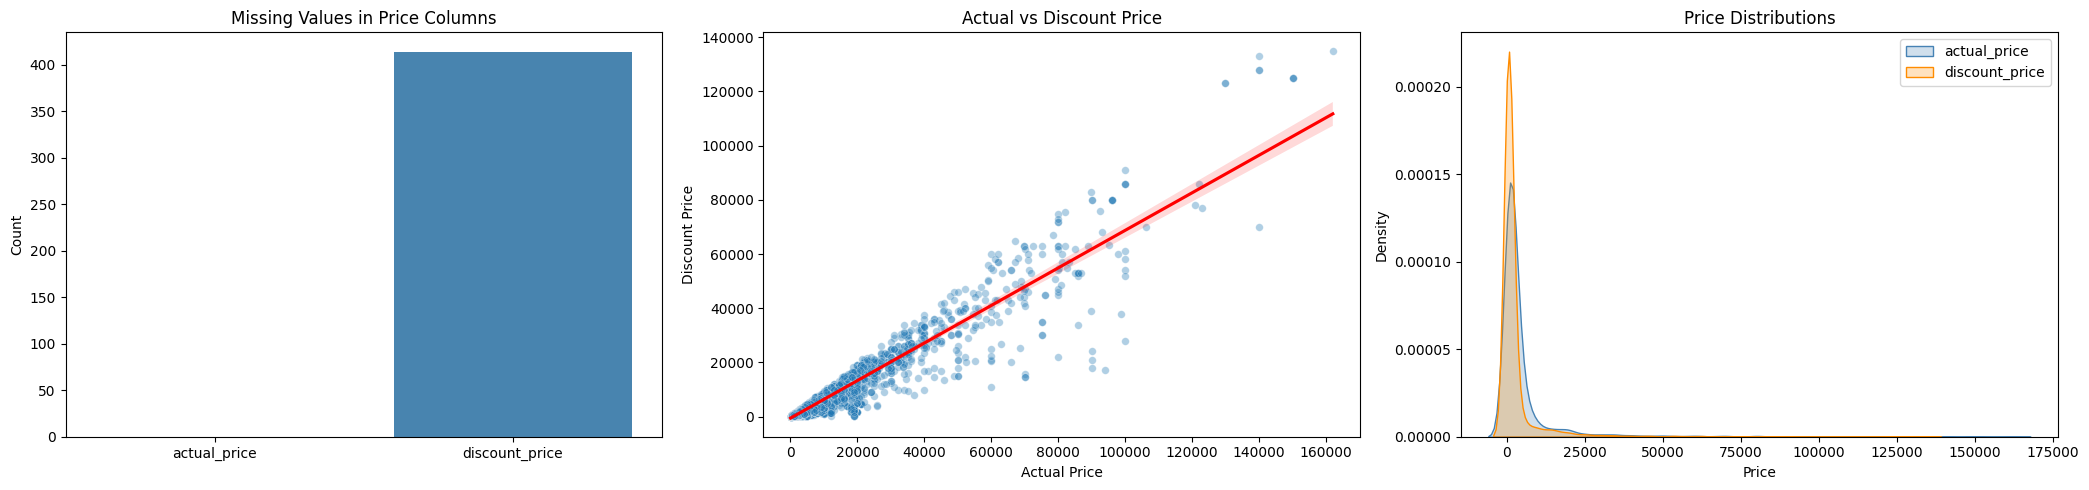

In [15]:

price_cols = ['actual_price', 'discount_price']
price_df = df[price_cols].copy()

for col in price_cols:
    price_df[col] = pd.to_numeric(
        price_df[col].astype(str).str.replace(r'[^0-9.]', '', regex=True),
        errors='coerce'
    )

print('Missing values after numeric conversion:')
print(price_df.isna().sum())

valid_prices = price_df.dropna()
print(f'Rows available for comparison: {len(valid_prices)}')

correlation = valid_prices.corr(numeric_only=True)
print('\nCorrelation matrix:')
print(correlation)

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

missing_counts = price_df.isna().sum()
sns.barplot(x=missing_counts.index, y=missing_counts.values, ax=axes[0], palette='Blues')
axes[0].set_title('Missing Values in Price Columns')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')

sns.scatterplot(data=valid_prices, x='actual_price', y='discount_price', alpha=0.35, ax=axes[1], s=30)
sns.regplot(data=valid_prices, x='actual_price', y='discount_price', scatter=False, ax=axes[1], color='red')
axes[1].set_title('Actual vs Discount Price')
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Discount Price')

sns.kdeplot(data=valid_prices, x='actual_price', ax=axes[2], color='steelblue', label='actual_price', fill=True, alpha=0.25)
sns.kdeplot(data=valid_prices, x='discount_price', ax=axes[2], color='darkorange', label='discount_price', fill=True, alpha=0.25)
axes[2].set_title('Price Distributions')
axes[2].set_xlabel('Price')
axes[2].legend()

plt.tight_layout()
plt.show()

In [16]:
df.dtypes

name              str
image             str
link              str
ratings           str
no_of_ratings     str
discount_price    str
actual_price      str
dtype: object

In [17]:
def clean_currency(x):
    """Removes ₹ and commas, converts to float."""
    if isinstance(x, str):
        x = x.replace('₹', '').replace(',', '').strip()
        # Sometimes prices are missing or have text like "Currently unavailable"
        try:
            return float(x)
        except ValueError:
            return np.nan
    return x

def clean_number(x):
    """Removes commas from numbers (like no_of_ratings) and converts to float."""
    if isinstance(x, str):
        x = x.replace(',', '').strip()
        try:
            return float(x)
        except ValueError:
            return np.nan
    return float(x) if pd.notnull(x) else np.nan

In [18]:
df['discount_price'] = df['discount_price'].apply(clean_currency)
df['actual_price'] = df['actual_price'].apply(clean_currency)

df['ratings'] = pd.to_numeric(df['ratings'], errors='coerce') 
df['no_of_ratings'] = df['no_of_ratings'].apply(clean_number)

print(df.dtypes)

name                  str
image                 str
link                  str
ratings           float64
no_of_ratings     float64
discount_price    float64
actual_price      float64
dtype: object


In [19]:
df = df.dropna(subset=['name'])

In [20]:

# 2. Fill missing ratings with 0
df['ratings'] = df['ratings'].fillna(0)
df['no_of_ratings'] = df['no_of_ratings'].fillna(0)

# 3. Fill missing prices (Optional: you can fill missing discount price with actual price)
df['discount_price'] = df['discount_price'].fillna(df['actual_price'])

# Drop duplicates just in case there are identical rows
df = df.drop_duplicates(subset=['name'])

print(f"Total products ready for modeling: {len(df)}")

Total products ready for modeling: 8733


In [21]:
df.to_csv('../data/processed/cleaned_amazon_products.csv',index=False)
print("cleaned data succesfully!")

cleaned data succesfully!
